# YOLO CAPTCHA Baseline  - Training & Evaluation

**Objectif**: Entraîner un modèle YOLOv8 pour la détection de caractères dans des CAPTCHAs.

- **Modèle**: yolov8s (small) au lieu de yolov8n (nano)
- **Early stopping**: patience=20 pour éviter l'overfitting
- **Augmentations renforcées**: rotation 15°, shear, perspective
- **Post-processing**: normalisation des caractères confusables (I/l, O/0)

## Structure du notebook
1. **Setup** - GPU, installations, imports, configuration
2. **Dataset** - Téléchargement Roboflow, vérification
3. **Training** - Entraînement YOLOv8 avec early stopping
4. **Inference** - Chargement modèle, reconstruction texte + normalisation
5. **Evaluation** - Métriques OCR avec/sans normalisation, analyse erreurs

---
# 1. Setup
GPU, installations et configuration globale

In [1]:
# ==================================================
# 1.1 Vérifier GPU
# ==================================================
!nvidia-smi

Thu Jan 29 03:06:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   38C    P8             11W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ==================================================
# 1.2 Installations
# ==================================================
!pip -q install -U ultralytics roboflow pyyaml opencv-python numpy
!yolo settings sync=False

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 138.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.1 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy

In [3]:
# ==================================================
# 1.3 Imports (TOUS les imports ici)
# ==================================================
import os
import glob
import random
from pathlib import Path
from collections import Counter

import yaml
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO
import ultralytics
from roboflow import Roboflow

# Vérification Ultralytics
ultralytics.checks()

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 39.2/112.6 GB disk)


In [ ]:
# ==================================================
# 1.4 Configuration Globale
# ==================================================
from dotenv import load_dotenv
load_dotenv()

# ----- Chemins -----
HOME = "/content"
DATASETS_DIR = f"{HOME}/datasets"
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/captcha_yolo_project"

# ----- Roboflow -----
ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")
ROBOFLOW_WORKSPACE = "testing-a8gzs"
ROBOFLOW_PROJECT = "yolo-captcha-test"
ROBOFLOW_VERSION = 7

# ----- Training (BASELINE AMÉLIORÉ) -----
MODEL_SIZE = "yolov8s.pt"  # UPGRADED: small > nano pour meilleure accuracy
EPOCHS = 120              # UPGRADED: plus d'epochs
PATIENCE = 20             # Early stopping: arrête si pas d'amélioration pendant 20 epochs
IMGSZ = 640
BATCH_SIZE = 16

# ----- Inference -----
CONF_THRESHOLD = 0.25  # Seuil de confiance (sera optimisé sur valid)
IOU_THRESHOLD = 0.6    # Pour le nettoyage des doublons

# ----- Evaluation -----
# IMPORTANT: On optimise sur VALID, on évalue sur TEST
TUNING_SPLIT = "valid"  # Pour le grid search (optimisation hyperparamètres)
FINAL_SPLIT = "test"    # Pour l'évaluation finale (1 seule fois)

# ----- Post-processing: gestion confusions I/l, 0/O -----
NORMALIZE_CONFUSIONS = False  # Mettre False si tu veux garder la distinction

# Créer les dossiers
os.makedirs(DATASETS_DIR, exist_ok=True)
print("Configuration chargée ✓")
print(f"  - Modèle: {MODEL_SIZE}")
print(f"  - Epochs: {EPOCHS} (patience: {PATIENCE})")
print(f"  - Grid search sur: {TUNING_SPLIT}")
print(f"  - Évaluation finale sur: {FINAL_SPLIT}")

In [5]:
# ==================================================
# 1.5 Monter Google Drive (pour sauvegarder le modèle)
# ==================================================
from google.colab import drive
drive.mount("/content/drive")

os.makedirs(f"{DRIVE_PROJECT_DIR}/models", exist_ok=True)
print(f"Drive monté. Modèles sauvegardés dans: {DRIVE_PROJECT_DIR}/models")

Mounted at /content/drive
Drive monté. Modèles sauvegardés dans: /content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/models


---
# 2. Dataset
Téléchargement depuis Roboflow et vérification

In [6]:
# ==================================================
# 2.1 Télécharger le dataset depuis Roboflow
# ==================================================
%cd {DATASETS_DIR}

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
dataset = project.version(ROBOFLOW_VERSION).download("yolov8")

DATASET_DIR = Path(dataset.location)
print(f"\nDataset téléchargé: {DATASET_DIR}")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Yolo-Captcha-Test-7 in yolov8:: 100%|██████████| 6870/6870 [00:00<00:00, 13066.38it/s]


Dataset téléchargé: /content/datasets/Yolo-Captcha-Test-7


In [7]:
# ==================================================
# 2.2 Corriger data.yaml (chemins relatifs standards)
# ==================================================
YAML_PATH = DATASET_DIR / "data.yaml"

with open(YAML_PATH, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

# Forcer les chemins standards YOLO
data_yaml["train"] = "../train/images"
data_yaml["val"] = "../valid/images"
data_yaml["test"] = "../test/images"

with open(YAML_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

# Charger les noms de classes (utilisés partout)
CLASS_NAMES = data_yaml["names"]
NUM_CLASSES = data_yaml["nc"]

print(f"data.yaml corrigé ✓")
print(f"Classes: {NUM_CLASSES} | Exemples: {CLASS_NAMES[:5]}...{CLASS_NAMES[-5:]}")

data.yaml corrigé ✓
Classes: 62 | Exemples: ['0', '1', '2', '3', '4']...['v', 'w', 'x', 'y', 'z']


In [8]:
# ==================================================
# 2.3 Vérification du dataset (sanity check)
# ==================================================
print("Split     | Images | Labels | OK")
print("-" * 40)

for split in ["train", "valid", "test"]:
    img_dir = DATASET_DIR / split / "images"
    lab_dir = DATASET_DIR / split / "labels"

    n_imgs = len(list(img_dir.glob("*.jpg"))) + len(list(img_dir.glob("*.png")))
    n_labs = len(list(lab_dir.glob("*.txt")))

    status = "✓" if n_imgs == n_labs and n_imgs > 0 else "✗"
    print(f"{split:9} | {n_imgs:6} | {n_labs:6} | {status}")

Split     | Images | Labels | OK
----------------------------------------
train     |   2415 |   2415 | ✓
valid     |    674 |    674 | ✓
test      |    340 |    340 | ✓


---
# 3. Training
Entraînement du modèle YOLOv8

In [ ]:
# ==================================================
# 3.1 Entraîner le modèle (BASELINE AMÉLIORÉ)
# ==================================================
model = YOLO(MODEL_SIZE)

results = model.train(
    data=str(YAML_PATH),
    epochs=EPOCHS,
    patience=PATIENCE,     
    imgsz=IMGSZ,
    batch=BATCH_SIZE,
    device=0,
    plots=False,

    # === Augmentations adaptées aux CAPTCHAs ===
    # Couleur
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    # Géométrie
    degrees=15,            # UPGRADED: rotation jusqu'à 15°
    translate=0.1,
    scale=0.4,             # UPGRADED: variation de taille
    shear=5,               # NOUVEAU: cisaillement léger
    perspective=0.0005,    # NOUVEAU: légère perspective

    # Désactivés (pas adaptés aux CAPTCHAs car mélangent les caractères)
    mosaic=0.0,
    mixup=0.0,

    # === Augmentations de dégradation (simule CAPTCHAs réels) ===
    # Note: ces params sont supportés dans Ultralytics récent
    # blur=0.1,            # Décommenter si supporté
    # noise=0.1,           # Décommenter si supporté
)

TRAIN_DIR = Path(results.save_dir)
print(f"\nEntraînement terminé!")
print(f"Dossier d'entraînement: {TRAIN_DIR}")
print(f"Meilleur modèle: {TRAIN_DIR / 'weights' / 'best.pt'}")

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/Yolo-Captcha-Test-7/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=

In [11]:
# ==================================================
# 3.2 Sauvegarder le meilleur modèle sur Drive
# ==================================================
import shutil

# Le meilleur modèle est dans runs/detect/train/weights/best.pt
best_model_src = TRAIN_DIR / "weights" / "best.pt"
best_model_dst = Path(f"{DRIVE_PROJECT_DIR}/models/best.pt")

if best_model_src.exists():
    shutil.copy(best_model_src, best_model_dst)
    print(f"Modèle sauvegardé: {best_model_dst}")
else:
    print("Modèle best.pt non trouvé. Vérifie le chemin.")

Modèle sauvegardé: /content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/models/best.pt


---
# 4. Inference
Chargement du modèle et reconstruction du texte

In [9]:
# ==================================================
# 4.1 Charger le modèle entraîné
# ==================================================
MODEL_PATH = f"{DRIVE_PROJECT_DIR}/models/best.pt"

model = YOLO(MODEL_PATH)
print(f"Modèle chargé: {MODEL_PATH} ✓")

Modèle chargé: /content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/models/best.pt ✓


In [10]:
# ==================================================
# 4.2 Fonctions utilitaires pour la reconstruction du texte
# ==================================================

def iou_xyxy(box_a, box_b):
    """
    Calcule l'IoU entre deux boxes [x1, y1, x2, y2].
    """
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    # Intersection
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)

    # Union
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    union = area_a + area_b - inter

    return inter / union if union > 0 else 0.0


def normalize_confusable_chars(text, mode="lowercase_preference"):
    """
    Normalise les caractères visuellement similaires.

    Modes:
    - "lowercase_preference": I -> l, O -> 0 (préfère minuscules/chiffres)
    - "uppercase_preference": l -> I, 0 -> O (préfère majuscules/lettres)
    - "none": pas de normalisation

    Confusions courantes dans les CAPTCHAs:
    - I (majuscule i) <-> l (minuscule L)
    - O (majuscule o) <-> 0 (zéro)
    - 1 (un) <-> l (minuscule L)
    """
    if mode == "none":
        return text

    if mode == "lowercase_preference":
        # Convertit vers les formes les plus courantes en minuscule/chiffre
        mapping = {
            'I': 'l',  # Majuscule I -> minuscule L
            'O': '0',  # Majuscule O -> chiffre 0
            # '1': 'l',  # Décommenter si le site confond aussi 1 et l
        }
    elif mode == "uppercase_preference":
        mapping = {
            'l': 'I',
            '0': 'O',
        }
    else:
        return text

    return ''.join(mapping.get(c, c) for c in text)


def decode_prediction(result, names, conf_threshold=0.25, iou_threshold=0.6, normalize=False):
    """
    Reconstruit le texte à partir des boxes YOLO.

    1. Filtre par confiance
    2. Supprime les doublons (NMS par IoU)
    3. Trie gauche -> droite
    4. Concatène les caractères
    5. (Optionnel) Normalise les caractères confusables

    Returns:
        text: str - Le texte reconstruit
        detections: list - Détails des boxes gardées
    """
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return "", []

    # 1. Extraire toutes les détections
    dets = []
    for b in boxes:
        conf = float(b.conf)
        if conf < conf_threshold:
            continue

        cls_id = int(b.cls)
        x1, y1, x2, y2 = map(float, b.xyxy[0])

        dets.append({
            "box": [x1, y1, x2, y2],
            "conf": conf,
            "char": names[cls_id],
            "x_center": (x1 + x2) / 2.0
        })

    if not dets:
        return "", []

    # 2. NMS maison: garder la meilleure box quand chevauchement
    dets.sort(key=lambda d: d["conf"], reverse=True)
    kept = []
    for d in dets:
        if all(iou_xyxy(d["box"], k["box"]) < iou_threshold for k in kept):
            kept.append(d)

    # 3. Trier gauche -> droite
    kept.sort(key=lambda d: d["x_center"])

    # 4. Reconstruire le texte
    text = "".join(d["char"] for d in kept)

    # 5. Normaliser les caractères confusables (optionnel)
    if normalize:
        text = normalize_confusable_chars(text, mode="lowercase_preference")

    return text, kept


def decode_ground_truth(label_path, names, normalize=False):
    """
    Reconstruit le texte GT depuis un fichier label YOLO.
    Format: class x_center y_center w h (normalisé)
    """
    if not label_path.exists():
        return ""

    items = []
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) >= 2:
            cls_id = int(float(parts[0]))
            x_center = float(parts[1])
            items.append((x_center, names[cls_id]))

    items.sort(key=lambda t: t[0])
    text = "".join(ch for _, ch in items)

    if normalize:
        text = normalize_confusable_chars(text, mode="lowercase_preference")

    return text


print("Fonctions de décodage chargées ✓")
print("  - normalize_confusable_chars(): gère I/l, O/0")
print("  - decode_prediction(): avec option normalize=True")

Fonctions de décodage chargées ✓
  - normalize_confusable_chars(): gère I/l, O/0
  - decode_prediction(): avec option normalize=True


Image: 375822933672_jpg.rf.730695b73d2be47e2b62311f5853e2b1.jpg

Sans normalisation:
  GT:   'auT2sH'
  Pred: 'auT2sH'
  Match: ✓

Avec normalisation (I->l, O->0):
  GT:   'auT2sH'
  Pred: 'auT2sH'
  Match: ✓


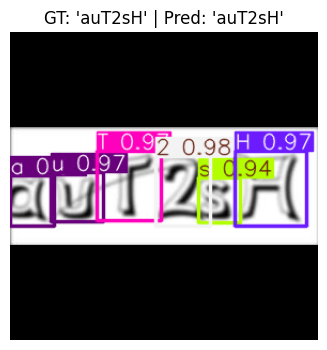

In [11]:
# ==================================================
# 4.3 Test rapide sur une image
# ==================================================
test_images = list((DATASET_DIR / "test" / "images").glob("*"))
img_path = random.choice(test_images)

print(f"Image: {img_path.name}")

# Prédiction
result = model.predict(str(img_path), conf=CONF_THRESHOLD, imgsz=IMGSZ, verbose=False)[0]

# Sans normalisation
text_raw, detections = decode_prediction(result, CLASS_NAMES, CONF_THRESHOLD, IOU_THRESHOLD, normalize=False)
# Avec normalisation
text_norm, _ = decode_prediction(result, CLASS_NAMES, CONF_THRESHOLD, IOU_THRESHOLD, normalize=True)

# Ground truth
label_path = DATASET_DIR / "test" / "labels" / f"{img_path.stem}.txt"
gt_text = decode_ground_truth(label_path, CLASS_NAMES, normalize=False)
gt_norm = decode_ground_truth(label_path, CLASS_NAMES, normalize=True)

print(f"\nSans normalisation:")
print(f"  GT:   '{gt_text}'")
print(f"  Pred: '{text_raw}'")
print(f"  Match: {'✓' if text_raw == gt_text else '✗'}")

print(f"\nAvec normalisation (I->l, O->0):")
print(f"  GT:   '{gt_norm}'")
print(f"  Pred: '{text_norm}'")
print(f"  Match: {'✓' if text_norm == gt_norm else '✗'}")

# Affichage
plt.figure(figsize=(12, 4))
plt.imshow(result.plot())
plt.axis("off")
plt.title(f"GT: '{gt_text}' | Pred: '{text_raw}'" + (f" -> Norm: '{text_norm}'" if text_raw != text_norm else ""))
plt.show()

---
# 5. Evaluation
- **5.2 Grid Search** → sur le **VALIDATION set** (optimisation hyperparamètres)
- **5.3 Évaluation finale** → sur le **TEST set** (métriques finales, 1 seule fois)

In [12]:
# ==================================================
# 5.1 Métriques: Exact Match et CER
# ==================================================

def levenshtein(a: str, b: str) -> int:
    """Distance d'édition Levenshtein."""
    if a == b:
        return 0
    if len(a) == 0:
        return len(b)
    if len(b) == 0:
        return len(a)

    dp = list(range(len(b) + 1))
    for i in range(1, len(a) + 1):
        prev = dp[0]
        dp[0] = i
        for j in range(1, len(b) + 1):
            temp = dp[j]
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[j] = min(dp[j] + 1, dp[j-1] + 1, prev + cost)
            prev = temp
    return dp[-1]


def cer(pred: str, gt: str) -> float:
    """Character Error Rate = levenshtein(pred, gt) / len(gt)"""
    if len(gt) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    return levenshtein(pred, gt) / len(gt)


print("Métriques définies ✓")

Métriques définies ✓


In [13]:
# ==================================================
# 5.2 Grid Search: trouver les meilleurs hyperparamètres
# ==================================================
# IMPORTANT: On utilise le VALIDATION set, pas le test set !
N_SAMPLES = 100  # Nombre d'images pour le grid search

# Préparer les images (VALIDATION set)
img_dir = DATASET_DIR / TUNING_SPLIT / "images"
lab_dir = DATASET_DIR / TUNING_SPLIT / "labels"
all_images = list(img_dir.glob("*"))
random.seed(42)
sample_images = random.sample(all_images, k=min(N_SAMPLES, len(all_images)))

# Grille de paramètres
grid_imgsz = [640, 960]  # 1280 souvent overkill pour CAPTCHA
grid_conf = [0.15, 0.25, 0.35, 0.45]
grid_iou = [0.4, 0.6, 0.8]  # NOUVEAU: seuil IoU pour le NMS

results_grid = []

print(f"Grid Search sur {TUNING_SPLIT} (N={len(sample_images)})...\n")
print(f"{'imgsz':>6} | {'conf':>5} | {'iou':>5} | {'ExactMatch':>10} | {'CER':>6}")
print("-" * 55)

for imgsz in grid_imgsz:
    for conf in grid_conf:
        for iou in grid_iou:
            exact = 0
            cers = []

            for img_path in sample_images:
                gt = decode_ground_truth(lab_dir / f"{img_path.stem}.txt", CLASS_NAMES)
                res = model.predict(str(img_path), conf=conf, imgsz=imgsz, verbose=False)[0]
                pred, _ = decode_prediction(res, CLASS_NAMES, conf, iou)  # iou variable

                if pred == gt:
                    exact += 1
                cers.append(cer(pred, gt))

            acc = exact / len(sample_images)
            mean_cer = np.mean(cers)
            results_grid.append((imgsz, conf, iou, acc, mean_cer))
            print(f"{imgsz:>6} | {conf:>5.2f} | {iou:>5.2f} | {acc:>10.3f} | {mean_cer:>6.3f}")

# Trier par ExactMatch (desc) puis CER (asc)
results_grid.sort(key=lambda x: (-x[3], x[4]))

print("\n" + "=" * 55)
print("Top 3 configurations:")
for i, (sz, cf, io, ac, ce) in enumerate(results_grid[:3], 1):
    print(f"  {i}. imgsz={sz}, conf={cf:.2f}, iou={io:.2f} -> Acc={ac:.3f}, CER={ce:.3f}")

# Sauvegarder la meilleure config
BEST_IMGSZ, BEST_CONF, BEST_IOU = results_grid[0][0], results_grid[0][1], results_grid[0][2]
print(f"\nMeilleure config (sur {TUNING_SPLIT}): imgsz={BEST_IMGSZ}, conf={BEST_CONF}, iou={BEST_IOU}")

Grid Search sur valid (N=100)...

 imgsz |  conf |   iou | ExactMatch |    CER
-------------------------------------------------------
   640 |  0.15 |  0.40 |      0.830 |  0.031
   640 |  0.15 |  0.60 |      0.850 |  0.028
   640 |  0.15 |  0.80 |      0.820 |  0.033
   640 |  0.25 |  0.40 |      0.830 |  0.031
   640 |  0.25 |  0.60 |      0.850 |  0.028
   640 |  0.25 |  0.80 |      0.830 |  0.031
   640 |  0.35 |  0.40 |      0.820 |  0.033
   640 |  0.35 |  0.60 |      0.840 |  0.029
   640 |  0.35 |  0.80 |      0.820 |  0.033
   640 |  0.45 |  0.40 |      0.820 |  0.033
   640 |  0.45 |  0.60 |      0.840 |  0.029
   640 |  0.45 |  0.80 |      0.840 |  0.029
   960 |  0.15 |  0.40 |      0.780 |  0.039
   960 |  0.15 |  0.60 |      0.800 |  0.036
   960 |  0.15 |  0.80 |      0.720 |  0.051
   960 |  0.25 |  0.40 |      0.790 |  0.038
   960 |  0.25 |  0.60 |      0.810 |  0.034
   960 |  0.25 |  0.80 |      0.740 |  0.046
   960 |  0.35 |  0.40 |      0.790 |  0.039
   960 |  

In [14]:
# ==================================================
# 5.3 Évaluation finale sur le TEST set
# ==================================================
# IMPORTANT: On utilise le TEST set ici (jamais vu pendant le tuning)
img_dir_final = DATASET_DIR / FINAL_SPLIT / "images"
lab_dir_final = DATASET_DIR / FINAL_SPLIT / "labels"
all_images = list(img_dir_final.glob("*"))

print(f"ÉVALUATION FINALE sur {len(all_images)} images ({FINAL_SPLIT})...")
print(f"Config utilisée: imgsz={BEST_IMGSZ}, conf={BEST_CONF}, iou={BEST_IOU} (optimisée sur {TUNING_SPLIT})\n")

# Métriques SANS normalisation
exact_raw = 0
cers_raw = []
errors_raw = []
confusions_raw = Counter()

# Métriques AVEC normalisation
exact_norm = 0
cers_norm = []

for img_path in all_images:
    # Ground truth
    gt_raw = decode_ground_truth(lab_dir_final / f"{img_path.stem}.txt", CLASS_NAMES, normalize=False)
    gt_norm = decode_ground_truth(lab_dir_final / f"{img_path.stem}.txt", CLASS_NAMES, normalize=True)

    # Prédiction
    res = model.predict(str(img_path), conf=BEST_CONF, imgsz=BEST_IMGSZ, verbose=False)[0]
    pred_raw, _ = decode_prediction(res, CLASS_NAMES, BEST_CONF, BEST_IOU, normalize=False)
    pred_norm, _ = decode_prediction(res, CLASS_NAMES, BEST_CONF, BEST_IOU, normalize=True)

    # --- Métriques sans normalisation ---
    if pred_raw == gt_raw:
        exact_raw += 1
    else:
        c = cer(pred_raw, gt_raw)
        errors_raw.append((img_path.name, gt_raw, pred_raw, c))
        for i in range(min(len(gt_raw), len(pred_raw))):
            if gt_raw[i] != pred_raw[i]:
                confusions_raw[(gt_raw[i], pred_raw[i])] += 1
    cers_raw.append(cer(pred_raw, gt_raw))

    # --- Métriques avec normalisation ---
    if pred_norm == gt_norm:
        exact_norm += 1
    cers_norm.append(cer(pred_norm, gt_norm))

cers_raw = np.array(cers_raw)
cers_norm = np.array(cers_norm)

# Affichage comparatif
print("=" * 60)
print(f"RÉSULTATS FINAUX SUR {FINAL_SPLIT.upper()}")
print("=" * 60)
print(f"{'Métrique':<25} | {'Sans norm':<12} | {'Avec norm':<12}")
print("-" * 60)
print(f"{'Exact Match Accuracy':<25} | {exact_raw/len(all_images):.3f} ({exact_raw:3d}) | {exact_norm/len(all_images):.3f} ({exact_norm:3d})")
print(f"{'CER moyen':<25} | {cers_raw.mean():.3f}        | {cers_norm.mean():.3f}")
print(f"{'CER médian':<25} | {np.median(cers_raw):.3f}        | {np.median(cers_norm):.3f}")
print(f"{'CER P90':<25} | {np.percentile(cers_raw, 90):.3f}        | {np.percentile(cers_norm, 90):.3f}")

# Gain de la normalisation
gain = exact_norm - exact_raw
print(f"\n{'Gain normalisation I/l,O/0':<25} : +{gain} images correctes ({gain/len(all_images)*100:.1f}%)")

# Pour la suite, on utilise les erreurs sans normalisation pour l'analyse
errors = errors_raw
confusions = confusions_raw
cers = cers_raw
exact = exact_raw

ÉVALUATION FINALE sur 340 images (test)...
Config utilisée: imgsz=640, conf=0.15, iou=0.6 (optimisée sur valid)

RÉSULTATS FINAUX SUR TEST
Métrique                  | Sans norm    | Avec norm   
------------------------------------------------------------
Exact Match Accuracy      | 0.865 (294) | 0.912 (310)
CER moyen                 | 0.027        | 0.017
CER médian                | 0.000        | 0.000
CER P90                   | 0.167        | 0.000

Gain normalisation I/l,O/0 : +16 images correctes (4.7%)


In [15]:
# ==================================================
# 5.4 Analyse des confusions
# ==================================================
print("Top 15 confusions (GT -> Pred):")
print("-" * 30)
for (g, p), n in confusions.most_common(15):
    print(f"  '{g}' -> '{p}' : {n} fois")

Top 15 confusions (GT -> Pred):
------------------------------
  'l' -> 'I' : 10 fois
  'I' -> 'l' : 9 fois
  'z' -> '9' : 1 fois
  'I' -> 'i' : 1 fois
  'G' -> 'l' : 1 fois
  '1' -> 'G' : 1 fois
  'g' -> '1' : 1 fois
  'U' -> 'g' : 1 fois
  'H' -> 'U' : 1 fois
  '8' -> 'l' : 1 fois
  'E' -> 'l' : 1 fois
  '1' -> 't' : 1 fois
  'i' -> 'b' : 1 fois
  'i' -> '4' : 1 fois
  '4' -> 'n' : 1 fois


Top 10 pires erreurs:
------------------------------------------------------------
1177206239374_jpg.rf.66794922f | GT='IxvNW' | Pred='lxvNWB' | CER=0.40
1007520985440_jpg.rf.01db26787 | GT='IX2Y0' | Pred='lX2Y0Q' | CER=0.40
606735198782_jpg.rf.0651071a16 | GT='IIaEV1' | Pred='llaEV1' | CER=0.33
923_jpg.rf.574ca247fff2d7868c5 | GT='r5M1ib' | Pred='r5Mtb' | CER=0.33
1514999515083_jpg.rf.9f12d5e25 | GT='7pQU6' | Pred='7pQU64' | CER=0.20
1619576321256_jpg.rf.086c6c375 | GT='PwzDT' | Pred='PwzDTq' | CER=0.20
480295208058_jpg.rf.dd20bdfbc7 | GT='TbuRR' | Pred='TbuRRT' | CER=0.20
1249928351040_jpg.rf.c13668d1b | GT='7l1UT' | Pred='7l1UTV' | CER=0.20
1000526119419_jpg.rf.2196401ce | GT='0eghP' | Pred='0eghPm' | CER=0.20
543_jpg.rf.b461bbbe16b8b39453f | GT='HCW2E' | Pred='HCW2EH' | CER=0.20


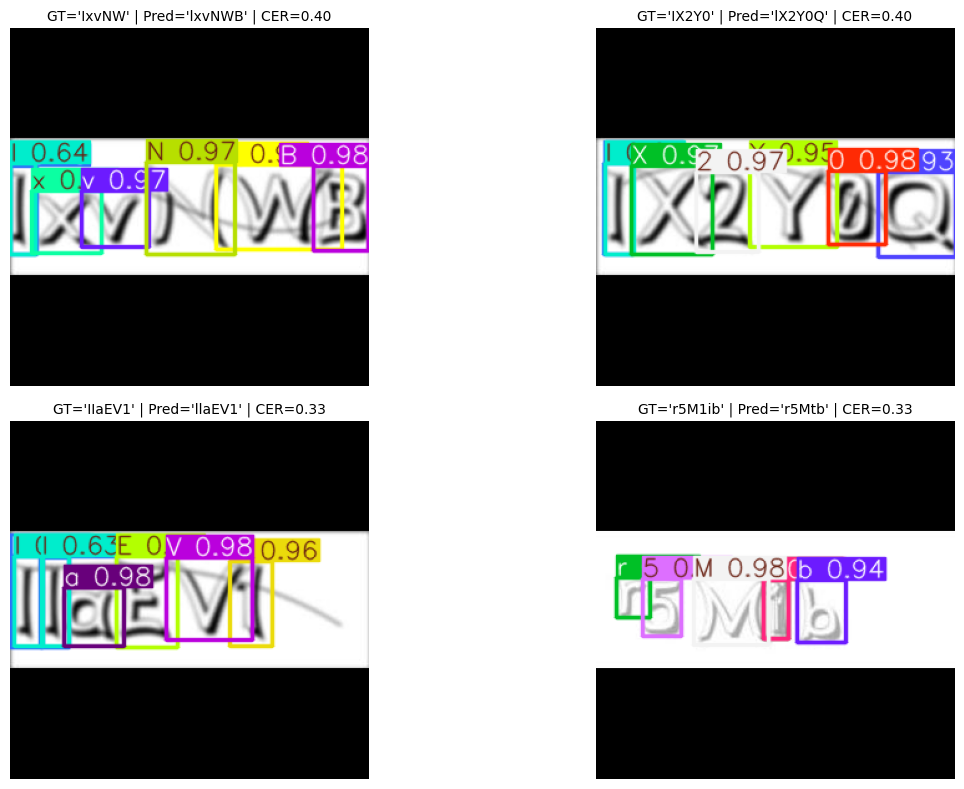

In [16]:
# ==================================================
# 5.5 Visualiser les pires erreurs
# ==================================================
errors_sorted = sorted(errors, key=lambda x: x[3], reverse=True)

print("Top 10 pires erreurs:")
print("-" * 60)
for name, gt, pred, c in errors_sorted[:10]:
    print(f"{name[:30]:30} | GT='{gt}' | Pred='{pred}' | CER={c:.2f}")

# Afficher les 4 pires
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (name, gt, pred, c) in zip(axes, errors_sorted[:4]):
    img_file = img_dir_final / name  # Utilise img_dir_final (test set)
    res = model.predict(str(img_file), conf=BEST_CONF, imgsz=BEST_IMGSZ, verbose=False)[0]

    ax.imshow(res.plot())
    ax.set_title(f"GT='{gt}' | Pred='{pred}' | CER={c:.2f}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Remarque**
- Le modèle baseline YOLOv8s performe mieux que les métriques ne le suggèrent.
- L'Accuracy de 86.5% est sous-estimé à cause des erreurs d'annotation dans le dataset Roboflow (caractères manquants dans le GT) .
- Le modèle est probablement à ~90%+ d'accuracy si on corrigeait les annotations.

---
# 6. Export 

## Résumé du baseline amélioré
| Paramètre | Ancienne valeur | Nouvelle valeur |
|-----------|-----------------|-----------------|
| Modèle | yolov8n.pt | **yolov8s.pt** |
| Epochs | 80 | **120** |
| Early stopping | Non | **patience=20** |
| Rotation | 10° | **15°** |
| Scale | 0.3 | **0.4** |
| Shear | 0 | **5** |
| Post-processing | Non | **Normalisation I/l, O/0** |


In [ ]:
# ==================================================
# 6.1 Sauvegarder les métriques
# ==================================================
metrics = {
    "model": MODEL_SIZE,
    "epochs": EPOCHS,
    "patience": PATIENCE,
    "tuning_split": TUNING_SPLIT,
    "final_split": FINAL_SPLIT,
    "best_imgsz": int(BEST_IMGSZ),
    "best_conf": float(BEST_CONF),
    "results": {
        "without_normalization": {
            "exact_match_accuracy": float(exact_raw / len(all_images)),
            "cer_mean": float(cers_raw.mean()),
            "cer_median": float(np.median(cers_raw)),
        },
        "with_normalization": {
            "exact_match_accuracy": float(exact_norm / len(all_images)),
            "cer_mean": float(cers_norm.mean()),
            "cer_median": float(np.median(cers_norm)),
        },
    },
    "normalization_gain": int(exact_norm - exact_raw),
    "top_confusions": [(f"{g}->{p}", n) for (g, p), n in confusions.most_common(10)],
    "augmentations": {
        "degrees": 15,
        "scale": 0.4,
        "shear": 5,
        "perspective": 0.0005,
        "mosaic": 0.0,
        "mixup": 0.0,
    }
}

metrics_path = f"{DRIVE_PROJECT_DIR}/models/baseline_metrics.yaml"
with open(metrics_path, "w") as f:
    yaml.dump(metrics, f, default_flow_style=False, allow_unicode=True)

print(f"Métriques sauvegardées: {metrics_path}")
print("\nRésumé:")
print(f"  - Hyperparamètres optimisés sur: {TUNING_SPLIT}")
print(f"  - Évaluation finale sur: {FINAL_SPLIT}")
print(f"  - Accuracy (sans norm): {metrics['results']['without_normalization']['exact_match_accuracy']:.3f}")
print(f"  - Accuracy (avec norm): {metrics['results']['with_normalization']['exact_match_accuracy']:.3f}")
print(f"  - Gain normalisation: +{metrics['normalization_gain']} images")

Métriques sauvegardées: /content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/models/baseline_metrics.yaml

Résumé:
  - Hyperparamètres optimisés sur: valid
  - Évaluation finale sur: test
  - Accuracy (sans norm): 0.865
  - Accuracy (avec norm): 0.912
  - Gain normalisation: +16 images
